In [2]:
import tensorflow as tf
from tensorflow import keras
from keras import layers
import numpy as np
import matplotlib.pyplot as plt


### PART A


In [4]:

(x_train,y_train),(x_test,y_test)=keras.datasets.mnist.load_data()

x_train=x_train/255.0
x_test=x_test/255.0

x_train=x_train.reshape(-1,784)
x_test=x_test.reshape(-1,784)

In [5]:
input_layer = keras.Input(shape=(784,))

# Encoder
x = layers.Dense(128,activation='relu')(input_layer)
x = layers.Dense(64,activation='relu')(x)
latent = layers.Dense(2)(x)

# Decoder
x = layers.Dense(64,activation='relu')(latent)
x = layers.Dense(128,activation='relu')(x)
output = layers.Dense(784,activation='sigmoid')(x)

autoencoder = keras.Model(input_layer,output)
encoder = keras.Model(input_layer,latent)

In [6]:
autoencoder.compile(optimizer='adam',loss='mse')

autoencoder.fit(
    x_train,
    x_train,
    epochs=30,
    batch_size=256,
    validation_data=(x_test,x_test)
)

Epoch 1/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0764 - val_loss: 0.0581
Epoch 2/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0548 - val_loss: 0.0520
Epoch 3/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0502 - val_loss: 0.0483
Epoch 4/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0470 - val_loss: 0.0463
Epoch 5/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0456 - val_loss: 0.0450
Epoch 6/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0444 - val_loss: 0.0439
Epoch 7/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0434 - val_loss: 0.0431
Epoch 8/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0427 - val_loss: 0.0426
Epoch 9/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0422 - val_loss: 0.0420
Epoch 10/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0417 - val_loss: 0.0415
Epoch 11/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0413 - val_loss: 0.0413
Epoch 12/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

In [7]:
latent_points = encoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


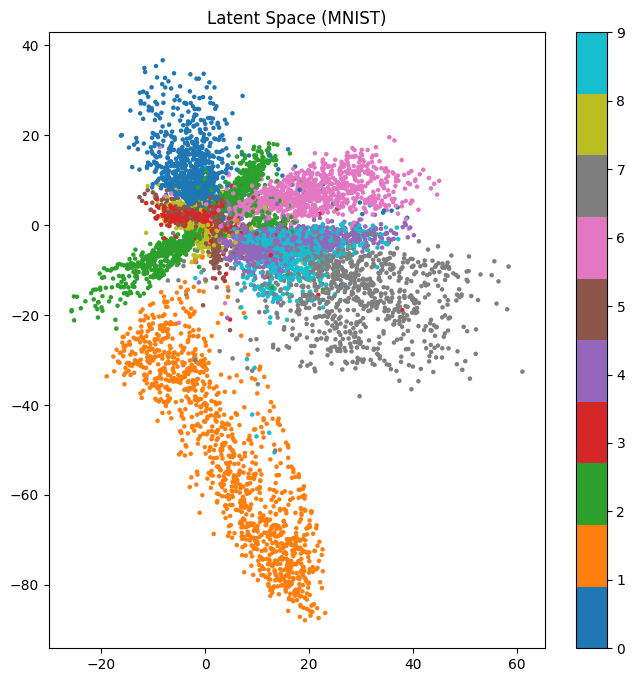

In [9]:
plt.figure(figsize=(8,8))

plt.scatter(
    latent_points[:,0],
    latent_points[:,1],
    c=y_test,
    cmap='tab10',
    s=5
)

plt.colorbar()
plt.title("Latent Space (MNIST)")
plt.show()

### PART B


In [16]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "tiny-imagenet/train",
    image_size=(64,64),
    batch_size=64
)

Found 3500 files belonging to 10 classes.


In [17]:
dataset = dataset.map(lambda x,y:(x/255.0,y))

In [18]:
images = []
labels = []

for x,y in dataset:
    images.append(x.numpy())
    labels.append(y.numpy())

images = np.concatenate(images)
labels = np.concatenate(labels)

print("Labels:", np.unique(labels))

Labels: [0 1 2 3 4 5 6 7 8 9]


In [19]:
ANOMALY_CLASS = np.unique(labels)[-1]

seen_images = images[labels != ANOMALY_CLASS]
unseen_images = images[labels == ANOMALY_CLASS]

print("Seen:", seen_images.shape)
print("Unseen:", unseen_images.shape)

Seen: (3150, 64, 64, 3)
Unseen: (350, 64, 64, 3)


In [20]:
input_img = keras.Input(shape=(64,64,3))

# Encoder
x = layers.Conv2D(32,3,activation='relu',padding='same')(input_img)
x = layers.MaxPooling2D(2,padding='same')(x)

x = layers.Conv2D(64,3,activation='relu',padding='same')(x)
x = layers.MaxPooling2D(2,padding='same')(x)

# Decoder
x = layers.Conv2DTranspose(64,3,strides=2,activation='relu',padding='same')(x)
x = layers.Conv2DTranspose(32,3,strides=2,activation='relu',padding='same')(x)

output = layers.Conv2D(3,3,activation='sigmoid',padding='same')(x)

autoencoder = keras.Model(input_img,output)

In [21]:
autoencoder.compile(optimizer='adam',loss='mse')

In [26]:
history = autoencoder.fit(
    seen_images,
    seen_images,
    epochs=30,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - loss: 0.0070 - val_loss: 0.0069
Epoch 2/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - loss: 0.0070 - val_loss: 0.0068
Epoch 3/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - loss: 0.0069 - val_loss: 0.0067
Epoch 4/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - loss: 0.0068 - val_loss: 0.0067
Epoch 5/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - loss: 0.0068 - val_loss: 0.0066
Epoch 6/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 0.0067 - val_loss: 0.0068
Epoch 7/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 0.0066 - val_loss: 0.0065
Epoch 8/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 0.0066 - val_loss: 0.0064
Epoch 9/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - loss: 0.0066 - val_loss: 0.0064
Epoch 10/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - loss: 0.0064 - val_loss: 0.0064
Epoch 11/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - loss: 0.0064 - val_loss: 0.0064
Epoch 12/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - loss: 0.0

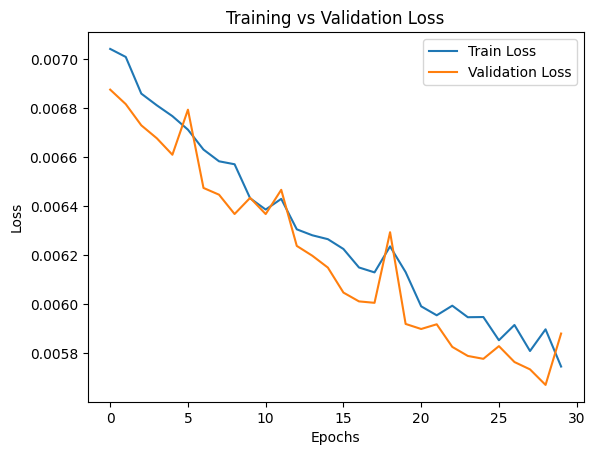

In [27]:
plt.figure()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

In [28]:
seen_pred = autoencoder.predict(seen_images)
unseen_pred = autoencoder.predict(unseen_images)

seen_error = np.mean((seen_images - seen_pred)**2,axis=(1,2,3))
unseen_error = np.mean((unseen_images - unseen_pred)**2,axis=(1,2,3))

print("Seen Error:", np.mean(seen_error))
print("Unseen Error:", np.mean(unseen_error))

99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Seen Error: 0.0059449095
Unseen Error: 0.006180599


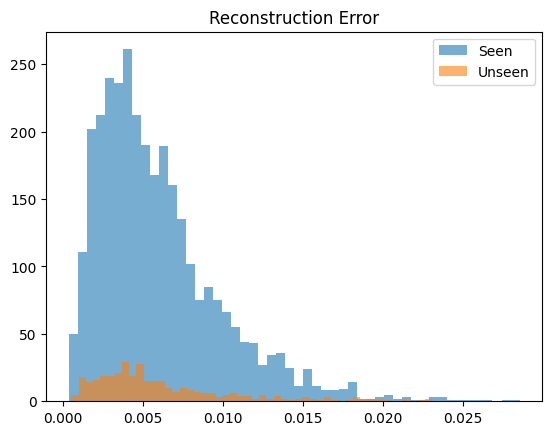

In [29]:
plt.hist(seen_error,bins=50,alpha=0.6,label="Seen")
plt.hist(unseen_error,bins=50,alpha=0.6,label="Unseen")

plt.legend()
plt.title("Reconstruction Error")
plt.show()

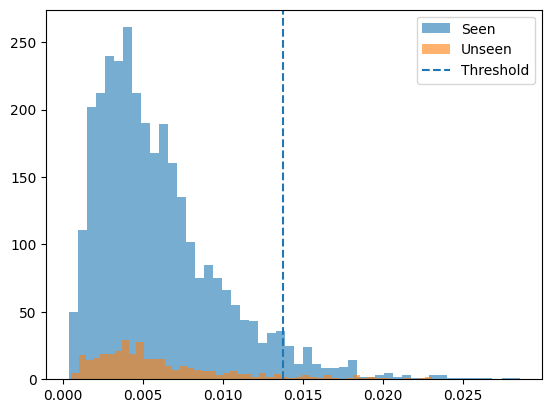

In [ ]:

threshold = np.mean(seen_error) + 2*np.std(seen_error)

plt.hist(seen_error,bins=50,alpha=0.6,label="Seen")
plt.hist(unseen_error,bins=50,alpha=0.6,label="Unseen")

plt.axvline(threshold, linestyle='--', label="Threshold")
plt.legend()
plt.show()